## This objective of this notebook is to map GLOBAL return periods
- Other notebooks will make Regional, Conflict Zones, Country, Admin, and Cell-year based return periods

#### First we need to set the working directory so relevant functions can be located

In [1]:
import os
import sys

# Get the current working directory
current_directory = os.getcwd()

# Print the current working directory
print("The current Working Directory is:", current_directory)

# Get the path to the base directory (VIEWS_FAO_index)
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
print(f'The base directory will be set to: {base_dir}')

# Add the base directory to sys.path
sys.path.insert(0, base_dir)

The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index


#### Next we load the functions

In [2]:
# delte this is temporary--
from src.utils.functions_for_graphics.individual_graphics.map_helper.manipulate_tables_for_mapping import calculate_histogram_data


from src.utils.universal_functions.setup.generate_base_file import give_primary_frame
from src.utils.universal_functions.setup.generate_percentiles import get_percentiles
from src.utils.universal_functions.setup.define_scale import select_scale

from src.utils.functions_for_return_periods.insurance_products_for_RP import insurance_files

from src.utils.universal_functions.setup.build_directory import float_to_custom_string, ensure_directory_exists


#Functions for graphics:
from src.utils.functions_for_graphics.construct_custom_symbology import user_defined_colormap, display_percentile_color_table, assign_color_to_zero_values


from src.utils.functions_for_graphics.individual_graphics.map_helper.manipulate_tables_for_mapping import clean_info_dataframe, query_and_sort_annual_table, provide_values_at_input_return_periods, retrieve_geodataframe, define_year_to_map, query_geodataframe

from src.utils.functions_for_graphics.individual_graphics.image_annual_returnperiod_table import image_save_returnperiodtable
from src.utils.functions_for_graphics.individual_graphics.image_annual_returnperiod_lineplot import plot_histogram_with_lineplot_4
from src.utils.functions_for_graphics.individual_graphics.image_annual_summary_table import plot_and_colorize_annual_table
from src.utils.functions_for_graphics.individual_graphics.image_map_for_Ei import image_save_map_E_i

#Mapping structure:
from src.utils.functions_for_graphics.layout_formats.event_cat_rp import map_event_cat_rp
from src.utils.functions_for_graphics.layout_formats.summary_of_top_years import map_top_years
#from src.utils.functions_for_graphics.layout_formats.Layout_single_method_option1 import mapped_option1


#functions for all methods
from src.utils.universal_functions.FAO_table_formatting.generate_output_tables import generate_and_give_info_dataframe, append_return_periods_to_annual_table

The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The current Working Directory is: /Users/gbenz/Documents/VIEWS_FAO_index/notebooks/methods
The base directory will be set to: /Users/gbenz/Documents/VIEWS_FAO_index
The curren

In [3]:
user_start_year = int(input("Enter a start year between 1989 and 2024: ").strip())
start_year = user_start_year - 1

user_end_year = int(input("Enter a end year between 1989 and 2024: ").strip())
end_year = user_end_year + 1

data = give_primary_frame('Fatalities_fao_pgm', 'cm_properties', start_year, end_year)

100%|██████████| 40.0M/40.0M [00:02<00:00, 14.3MB/s]


Queryset Fatalities_fao_pgm read successfully 
Queryset cm_properties read successfully 
['month_id', 'pg_id', 'C_start_year', 'C_end_year', 'pop_gpw_sum', 'country_name', 'ged_sb', 'ged_ns', 'ged_os', 'year', 'fatalities_sum', 'country_id']


In [4]:
#display(data)
data_working_copy = data.copy()
unique_countries = data_working_copy['country_name'].unique()
print(unique_countries)

['South Africa' 'Lesotho' 'Swaziland' 'Botswana' 'Mozambique' 'Madagascar'
 'Zimbabwe' 'Mauritius' 'Angola' 'Zambia' 'Malawi' 'Congo, DRC' 'Comoros'
 'Tanzania' 'Seychelles' 'Congo' 'Burundi' 'Kenya' 'Gabon' 'Rwanda'
 'Somalia' 'Uganda' 'Sao Tome and Principe' 'Equatorial Guinea' 'Cameroon'
 'Central African Republic' 'Sudan' 'Ethiopia' 'Liberia' "Cote d'Ivoire"
 'Nigeria' 'Ghana' 'Togo' 'Benin' 'Sierra Leone' 'Guinea' 'Chad'
 'Burkina Faso' 'Mali' 'Guinea-Bissau' 'Djibouti' 'Senegal' 'Niger'
 "Yemen People's Republic" 'The Gambia' 'Yemen Arab Republic' 'Cape Verde'
 'Mauritania' 'Saudi Arabia' 'Oman' 'Libya' 'Algeria' 'Morocco' 'Egypt'
 'United Arab Emirates' 'Qatar' 'Iran' 'Pakistan' 'Bahrain' 'Kuwait'
 'Jordan' 'Iraq' 'Afghanistan' 'Israel' 'Tunisia' 'Syria' 'Lebanon'
 'Turkey' 'USSR' 'Greece' 'Bulgaria' 'Namibia' 'Yemen' 'Georgia'
 'Turkmenistan' 'Azerbaijan' 'Armenia' 'Eritrea' 'South Sudan']


#### Then we determine percentiles from the `global` data.

- Because the scale is global, there will be a single aggregated summary 

In [ ]:
import numpy as np
import pandas as pd

# Compute percentiles 1 to 100
percentile_values = {p: np.percentile(data['fatalities_sum'], p) for p in range(1, 101)}
print(percentile_values)
# Convert to DataFrame
percentile_df = pd.DataFrame(list(percentile_values.items()), columns=['Percentile', 'Value'])

display(percentile_df)

#### 99th Percentile = 0

This analysis shows that a fatality value of 1 appears between the 99th and 100th percentile, demonstrating that any occasion of violence, across the global PGM level, is considered to be within the 1 in 100 year return period. 

In [5]:
country = select_scale(unique_countries)

print(f'Country selection is: {country}')
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
user_value_field = input("Select a field ('Raw fatalities' or 'Per capita fatalities'): ").strip()
if user_value_field == 'Raw fatalities':
    value_field = 'fatalities_sum'

if user_value_field == 'Per capita fatalities':
    value_field = 'percapita_100k'

#value_field = 'fatalities_sum' # or fatalities_sum or percapita_100k

print(f'Value field selection is: {value_field}')
print()

method = input("Select a unit of analysis or special data treatment: ('standard', 'aggregation', or 'smoothing'): ").strip()

#method = 'standard' # 'standard' or 'aggregation' or 'smoothing'
print(f'Method selection is: {method}')
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#No need to change -- elements are dependant on the input above:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if method == 'smoothing':
    value_field = 'perca_Mean'

print(value_field)
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
return_period = input("Select a return period calculation: ('Country year', or 'Event year'): ").strip()

#return_period = 'Country year' # 'Event year' or 'Country year'
print(f'Return period calculation: {return_period}')
print()
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#No need to change -- elements are dependant on the input above:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if return_period == 'Event year':
    insurance_attribute = 'return period' # This should eventually be changed and cleaned up
if return_period == 'Country year':
    insurance_attribute = 'Return Period' # This should eventually be changed and cleaned up
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if method == 'aggregation':
    aggregation = value = str(int(input("Enter an aggregation unit from 2 to 10: ").strip()))


#aggregation = '3'
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#No need to change -- elements are dependant on the input above:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
if method == 'aggregation' and int(aggregation) <= 1:
    raise ValueError("Aggregation value must be greater than 1 for the 'aggregation' method.")

if method == 'standard' or method == 'smoothing':
    aggregation = '1'
print(f'Aggregation Unit: {aggregation}')
#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Default is ['90','95','98','99']

# User should select from 
#   1. User defined
# If this is prompted then allow user to input a list of values.
# A new function will need to be written that transforms the user defined values to a string and create a list

#   2. Default which should then generate a list of ['90','95','98','99']

#   3. 'All Values'
#   If 'All Values' is entered the function should generate a list starting at 1 and go up to 100 with .5 increases starting at 95.0
#   lst = [i if i <= 95 else 95 + 0.5 * (j - 94) for j, i in enumerate(range(1, 96), start=1)] + [i / 2 for i in range(191, 201)]

option = input("Choose an option to calculate percentiles ('Default', 'User defined', 'All values'): ")
percentiles = get_percentiles(option)
print(percentiles)



Available countries:
South Africa
Lesotho
Swaziland
Botswana
Mozambique
Madagascar
Zimbabwe
Mauritius
Angola
Zambia
Malawi
Congo, DRC
Comoros
Tanzania
Seychelles
Congo
Burundi
Kenya
Gabon
Rwanda
Somalia
Uganda
Sao Tome and Principe
Equatorial Guinea
Cameroon
Central African Republic
Sudan
Ethiopia
Liberia
Cote d'Ivoire
Nigeria
Ghana
Togo
Benin
Sierra Leone
Guinea
Chad
Burkina Faso
Mali
Guinea-Bissau
Djibouti
Senegal
Niger
Yemen People's Republic
The Gambia
Yemen Arab Republic
Cape Verde
Mauritania
Saudi Arabia
Oman
Libya
Algeria
Morocco
Egypt
United Arab Emirates
Qatar
Iran
Pakistan
Bahrain
Kuwait
Jordan
Iraq
Afghanistan
Israel
Tunisia
Syria
Lebanon
Turkey
USSR
Greece
Bulgaria
Namibia
Yemen
Georgia
Turkmenistan
Azerbaijan
Armenia
Eritrea
South Sudan

Options:
1. Enter 'Global' to analyze all data as one entity.
2. Enter one or more country names separated by commas.
3. Enter 'Process all countries' to analyze each country individually.
Country selection is: ['Ethiopia']

Value field se

In [6]:
# def insurance_files(data, country_name, method, return_period_process, percentiles=['90','95','98','99','100'], aggregation_unit='0', eval_field='percapita_100k'):

#conflict_profile, x, y, z = insurance_files(data_working_copy, country, method, return_period, percentiles, aggregation_unit=aggregation, eval_field=value_field)
country_dictionary = insurance_files(data_working_copy, country, method, return_period, percentiles, aggregation_unit=aggregation, eval_field=value_field)


# print(x.head(10))
# print('y dataframe')
# print(y)
# print('z dataframe:')
# print(z)

# max_year = max(x['year'])
# min_year = min(x['year'])

# print(max_year)
# print(min_year)

   c_id country_name  C_start_year  C_end_year       0
0    57     Ethiopia          1993        2050  141325
1   191     Ethiopia          1946        1993   22112
the length of country_ids for the selected country is: 2
Processing Ethiopia...
Printing the country and year dictionary:
{57: (1993, 2050), 191: (1946, 1993)}
Index where fatalities_sum equals 1 (fatalities) or 0.1 (per capita): 93.4: 1.0


In [107]:
pd.set_option("display.max_rows", 50)

country_dictionary

{'Ethiopia': {'conflict profile': {'ged_sb': 296056.0,
   'ged_ns': 8280.0,
   'ged_os': 12045.0,
   'fatalities_sum': 316381.0},
  'PGY dataframe':         pg_id  year  fatalities_sum   pop_gpw_sum  percapita_100k
  0      135077  1993             0.0  15539.840820             0.0
  1      135077  1994             0.0  16002.742188             0.0
  2      135077  1995             0.0  16465.642578             0.0
  3      135077  1996             0.0  16904.835938             0.0
  4      135077  1997             0.0  17344.029297             0.0
  ...       ...   ...             ...           ...             ...
  11928  153799  1993             0.0  12792.661133             0.0
  11929  154517  1993             0.0  58059.253906             0.0
  11930  154518  1993             0.0  53144.750000             0.0
  11931  154519  1993             0.0    462.310638             0.0
  11932  155238  1993             0.0  25482.050781             0.0
  
  [11933 rows x 5 columns],
  'ann

In [7]:
import pandas as pd
df_return_period = country_dictionary['Ethiopia']['return period table']
pd.set_option('display.max_rows', None)

display(df_return_period)

,Percentile,fatalities_sum,Occurrence,Return Period,Payout Rate
0,1,0.0,0,1.0,undefined
1,2,0.0,0,1.0,undefined
2,3,0.0,0,1.0,undefined
3,4,0.0,0,1.0,undefined
4,5,0.0,0,1.0,undefined
5,6,0.0,0,1.0,undefined
6,7,0.0,0,1.0,undefined
7,8,0.0,0,1.0,undefined
8,9,0.0,0,1.0,undefined
9,10,0.0,0,1.1,undefined


### If you were to run the previous tool with standard (1x1) treatment applied, why is the value of 1.0 fatality appear at 96.6 rather than 99.x in the code above?

This is because the preceding cell is taking PGY values rather than PGM data.

### Now we progress toward the mapping workflow

In [9]:
info_df, color_scheme = generate_and_give_info_dataframe(df_return_period, return_period, value_field, insurance_attribute)

info_df

Updated row 0 with values from row 1: 0.0, 0


,Return Period,Range,Color,Label
0,0,0 - 0.0,#d5dbdb,Below 1 in 10 year
1,10,0.0 - 3.0,#377eb8,1 in 10 year
2,20,3.0 - 25.0,#e6ab02,1 in 20 year
3,50,25.0 - 63.0,#762a83,1 in 50 year
4,100,63.0 - 100000,#b2182b,1 in 100 year


#### Here we will create a custom mapper function to assign unique hex color codes to each return period mapped from the previous step

- the following code works perfectly


Available Colors:
black, white, gray, silver, lightgray, darkgray, red, darkred, lightcoral, indianred, salmon, darksalmon, tomato, orangered, firebrick, brown, maroon, orange, darkorange, gold, yellow, lightyellow, khaki, olive, darkolivegreen, green, darkgreen, forestgreen, lime, limegreen, lightgreen, palegreen, springgreen, seagreen, mediumseagreen, mediumspringgreen, teal, darkcyan, cyan, lightcyan, aqua, aquamarine, turquoise, mediumturquoise, darkturquoise, steelblue, deepskyblue, dodgerblue, blue, mediumblue, darkblue, navy, royalblue, cornflowerblue, skyblue, lightskyblue, slateblue, mediumslateblue, darkslateblue, purple, mediumorchid, darkorchid, darkviolet, violet, blueviolet, indigo, magenta, darkmagenta, fuchsia, plum, orchid, thistle, pink, lightpink, hotpink, deeppink, mediumvioletred

You entered 8 thresholds. Now, enter 8 colors corresponding to them.

Percentile to Color Mapping:
  1.0: gray
  85.0: cyan
  90.0: blue
  95.0: green
  97.5: yellow
  99.0: orange
  99.

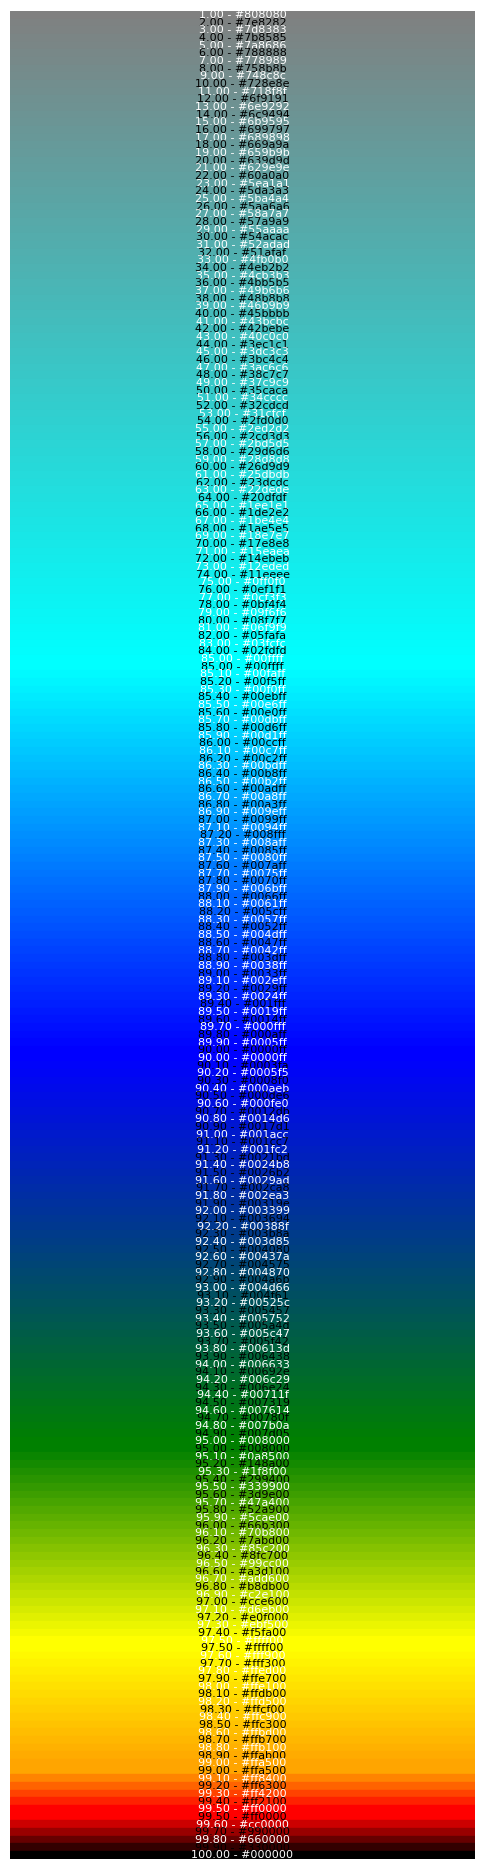

In [108]:

dynamic_colormap_df_corrected = user_defined_colormap()
print(dynamic_colormap_df_corrected)
# Display the color table for percentiles
display_percentile_color_table(dynamic_colormap_df_corrected)

In [122]:

pd.set_option("display.max_rows", 100)

df_return_period["Percentile"] = df_return_period["Percentile"].astype(float).round(1)
dynamic_colormap_df_corrected["Percentile"] = dynamic_colormap_df_corrected["Percentile"].astype(float).round(1)

# Perform the join based on the shared Percentile column
df_merged = df_return_period.merge(dynamic_colormap_df_corrected, on="Percentile", how="left")

# Prompt user to enter a color name for zero values
zero_value_color_name = input("Enter the color name to assign to zero values (e.g., 'blue', 'red', 'green'): ")

# Apply the function with user input
df_updated = assign_color_to_zero_values(df_merged, zero_value_color_name)

# Display the updated DataFrame
print(df_updated)

    Percentile  fatalities_sum  Occurrence Return Period Payout Rate hex_value
0         93.0             0.0       11142          14.2   undefined   #808080
1         93.4             1.0           0          15.1   undefined   #005752
2         94.0             1.0         183          16.6   undefined   #006633
3         95.0             3.0          58          20.0         55%   #008000
5         95.5             4.0          42          22.2   undefined   #339900
6         96.0             5.0          66          25.0   undefined   #66b300
7         96.5             7.0          76          28.5   undefined   #99cc00
8         97.0            11.0          62          33.3   undefined   #cce600
9         97.5            16.0          57          40.0   undefined   #ffff00
11        98.0            25.0          68          50.0         75%   #ffe100
12        98.5            37.0          58          66.6   undefined   #ffc300
13        99.0            63.0          61         1